### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [30]:
data = pd.read_csv('data/coupons.csv')

In [31]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

In [33]:
#data.isna().sum()
data.isna().mean().sort_values(ascending=False)*100
# I want to view the percentage of cells tha have null values for each column


car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
destination              0.000000
passanger                0.000000
direction_opp            0.000000
direction_same           0.000000
toCoupon_GEQ25min        0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ5min         0.000000
income                   0.000000
occupation               0.000000
education                0.000000
has_children             0.000000
maritalStatus            0.000000
age                      0.000000
gender                   0.000000
expiration               0.000000
coupon                   0.000000
time                     0.000000
temperature              0.000000
weather                  0.000000
Y                        0.000000
dtype: float64

Text(0.5, 1.0, 'Types of Cars')

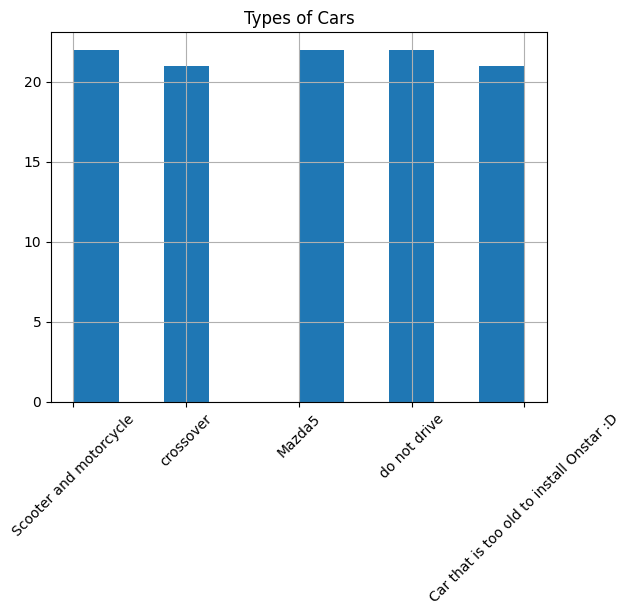

In [34]:
#sns.histplot(data['car'].dropna())
data['car'].dropna().hist(xrot=45)
plt.title("Types of Cars")

#we can see below that the 'car' column does not have menaingful or organized information
# and 99% of entries are missing info about this, so it is best to drop the 'car' column

Text(0.5, 1.0, 'Bar Visit Frequencies')

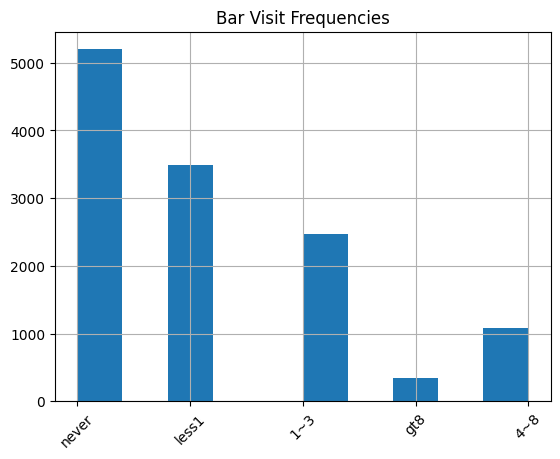

In [35]:
data['Bar'].dropna().hist(xrot=45)
plt.title("Bar Visit Frequencies")
#data['CoffeeHouse'].dropna().hist(xrot=45)
#data['CarryAway'].dropna().hist(xrot=45)
#data['RestaurantLessThan20'].dropna().hist(xrot=45)
#data['Restaurant20To50'].dropna().hist(xrot=45)


#all other columns with some missing data have useful information

3. Decide what to do about your missing data -- drop, replace, other...

In [36]:
data = data.drop('car', axis=1, inplace=False, columns=None)
#Drop 'car' column alltogether

In [37]:
cols = ['Bar', 'CoffeeHouse', 'CarryAway','RestaurantLessThan20','Restaurant20To50']
data[cols] = data[cols].fillna(data[cols].mode().iloc[0])
# filling missing entries with the mode or each column (better than null and will not cause a skew because only ~1% or entries gett filled)
data.isna().sum().sum() #shows there are 0 null values now

0

4. What proportion of the total observations chose to accept the coupon?



In [38]:
proportion_accepted = data['Y'].mean()
print(proportion_accepted)
# 0.568 (or 56.8%) of coupons were accepted

0.5684326710816777


5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Types of Coupons')

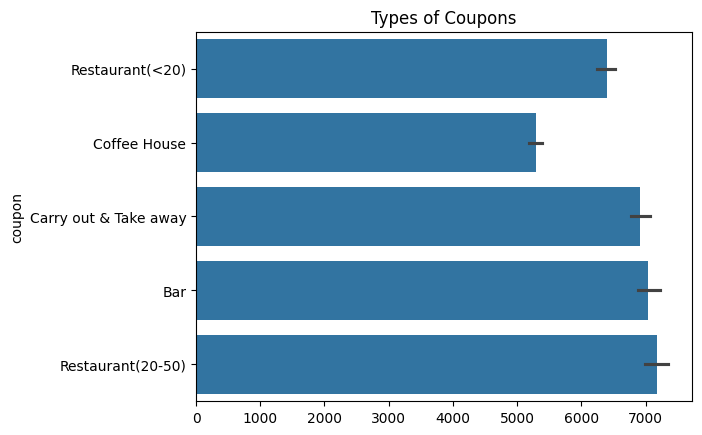

In [39]:
sns.barplot(data['coupon'])
plt.title("Types of Coupons")

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Temperatures Measured During Experiment')

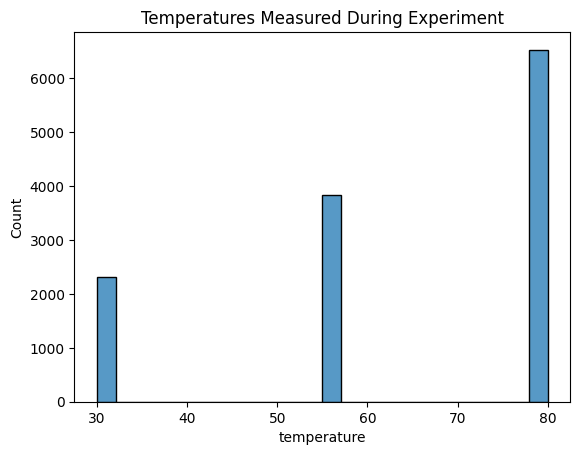

In [40]:
sns.histplot(data['temperature'])
plt.title("Temperatures Measured During Experiment")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [41]:
bar_df = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [42]:
bars_accepted = bar_df['Y'].mean()
print("The acceptance rate for all who recieved a bar coupon is " + str(round(bars_accepted,3)))#0.41 (or 41%) of bar coupons were accepted

The acceptance rate for all who recieved a bar coupon is 0.41


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [43]:
low_freq_acceptance_rate = bar_df[bar_df['Bar'].isin(['never','less1','1~3'])]['Y'].mean()
high_freq_acceptance_rate = bar_df[bar_df['Bar'].isin(['4~8','gt8'])]['Y'].mean()
print("The acceptance rate for those who went to a bar 3 or fewer times a month is " + str(round(low_freq_acceptance_rate, 3)))
print("The acceptance rate for those who went to a bar 4 or more times a month is " + str(round(high_freq_acceptance_rate, 3)))

The acceptance rate for those who went to a bar 3 or fewer times a month is 0.371
The acceptance rate for those who went to a bar 4 or more times a month is 0.769


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [44]:
# Group A consists of people over the age of 25 who go to bars 1 or more times a month
group_a = bar_df[ 
    (bar_df['Bar'].isin(['1~3','4~8','gt8']))  &     
    (bar_df['age'].isin(['26','31','36','41','46','50plus']))
    ]
# Group B is all the others
group_b = bar_df[ 
    ~((bar_df['Bar'].isin(['1~3','4~8','gt8']))  &     
    (bar_df['age'].isin(['26','31','36','41','46','50plus'])))
    ]
group_a_rate = group_a['Y'].mean()
group_b_rate = group_b['Y'].mean()
print("The acceptance rate for persons 25+ years who go 1 or more times a month is " + str(round(group_a_rate, 3)))
print("The acceptance rate for all others is " + str(round(group_b_rate, 3)))

The acceptance rate for persons 25+ years who go 1 or more times a month is 0.695
The acceptance rate for all others is 0.335


In [45]:
sorted(data['age'].unique()) # using this to see all the possible ages

['21', '26', '31', '36', '41', '46', '50plus', 'below21']

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [46]:
group_a = bar_df[ 
    (bar_df['Bar'].isin(['1~3','4~8','gt8']))  &     
    (bar_df['passanger'].isin(['Alone','Friend(s)','Partner'])) &
    (~(bar_df['occupation'].isin(['Farming Fishing & Forestry'])))
    ]
group_b = bar_df[ 
    (bar_df['Bar'].isin(['1~3','4~8','gt8']))  &     
    (bar_df['passanger'].isin(['Kid(s)'])) &
    (~(bar_df['occupation'].isin(['Farming Fishing & Forestry'])))
    ]

group_a_rate = group_a['Y'].mean()
group_b_rate = group_b['Y'].mean()
print("Rate for bars >1 a month, had passengers that were not a kid and had jobs other than FF&F: " + str(round(group_a_rate,3)))
print("Rate for bars >1 a month, had passengers that were kids and had jobs other than FF&F: " + str(round(group_b_rate,3)))


Rate for bars >1 a month, had passengers that were not a kid and had jobs other than FF&F: 0.713
Rate for bars >1 a month, had passengers that were kids and had jobs other than FF&F: 0.378


In [47]:
Bars_FFF = bar_df[bar_df['occupation'].isin(['Farming Fishing & Forestry'])]
# I want to see the full table to invesntigate why including FFF jobs does not affect the acceptance rate in the above answer
Bars_FFF.to_csv('data/Bars_FFF_table.csv', index=False) #FFF is Farming Fishing & Forestry

Text(0.5, 1.0, 'Types of Occupations')

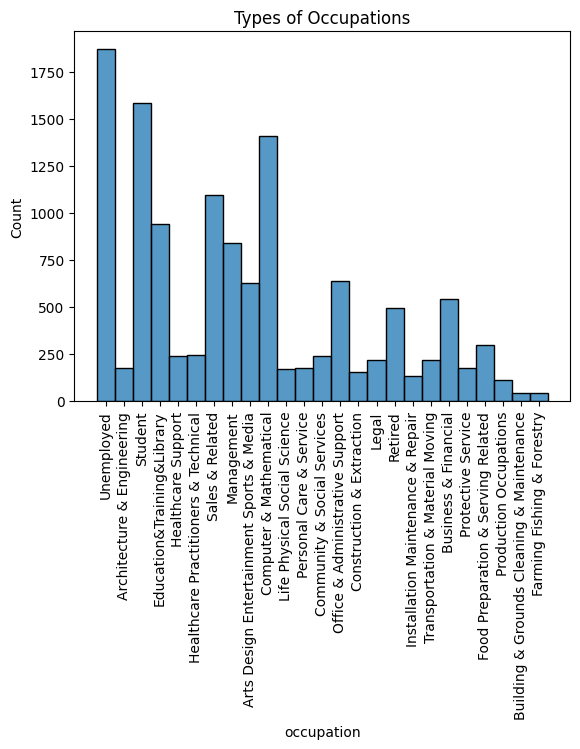

In [48]:
sns.histplot(data['occupation'])
plt.xticks(rotation=90);
plt.title("Types of Occupations")
# I want to view all possible occupations

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [49]:
group_a = bar_df[ 
    (bar_df['Bar'].isin(['1~3','4~8','gt8']))  &     
    (bar_df['passanger'].isin(['Alone','Friend(s)','Partner'])) &
    (~(bar_df['maritalStatus'].isin(['Widowed'])))
    ]
group_b = bar_df[ 
    (bar_df['Bar'].isin(['1~3','4~8','gt8']))  &     
    (bar_df['age'].isin(['26','21','below21']))
    ]
group_c = bar_df[ 
    (bar_df['RestaurantLessThan20'].isin(['4~8','gt8']))  &     
    (bar_df['income'].isin(['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']))
    ]

group_a_rate = group_a['Y'].mean()
group_b_rate = group_b['Y'].mean()
group_c_rate = group_c['Y'].mean()

print("Key Rates:")
print("- Bars >1 a month,  passengers not a kid, and not widowed: " + str(round(group_a_rate,3)))
print("- Bars >1 a month and are under the age of 30: " + str(round(group_b_rate,3)))
print("- Cheap restaurants >4 a month and income <50K: " + str(round(group_c_rate,3)))


Key Rates:
- Bars >1 a month,  passengers not a kid, and not widowed: 0.713
- Bars >1 a month and are under the age of 30: 0.722
- Cheap restaurants >4 a month and income <50K: 0.453


In [50]:
data['income'].unique() # using this to see all the possible income ranges

array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

#### **Question 7 answers**
- Drivers who regularly go to bars are much more likely to accept a bar coupon than those who dont go often.
- Drivers who have adult passengers are far more likely to accept the coupon than those with kids in the car.
- Overall, a driver's bar visit frequency is the strongest inicator of a bar coupon acceptance


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [51]:
# I want to investigate the Coffee House (I will say cafe for short) coupon group
cafe_df = data[data['coupon'] == 'Coffee House']
cafe_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0


In [52]:
# Overall acceptance rate
cafes_accepted = cafe_df['Y'].mean()
print("The acceptance rate for all who recieved a Coffee House coupon is " + str(round(cafes_accepted,3)))

The acceptance rate for all who recieved a Coffee House coupon is 0.499


In [53]:
# Studying the affect of a drivers monthly cafe visits on the coupon acceptance rate
less1_rate = cafe_df[cafe_df['CoffeeHouse'].isin(['never','less1'])]['Y'].mean()
one_plus_rate = cafe_df[cafe_df['CoffeeHouse'].isin(['1~3','4~8','gt8'])]['Y'].mean()
four_plus_rate = cafe_df[cafe_df['CoffeeHouse'].isin(['4~8','gt8'])]['Y'].mean()

print("Key Cafe Acceptance Rates:")
print("- Went to a cafe <1 times a month: " + str(round(less1_rate, 3)))
print("- Went to a cafe >1 times a month: " + str(round(one_plus_rate, 3)))
print("- Went to a cafe >4 times a month: " + str(round(four_plus_rate, 3)))

Key Cafe Acceptance Rates:
- Went to a cafe <1 times a month: 0.35
- Went to a cafe >1 times a month: 0.66
- Went to a cafe >4 times a month: 0.675


In [54]:
# Studying the affect of age on cafe acceptance rate
group_a = cafe_df[
    (cafe_df['age'].isin(['below21']))
]
group_b = cafe_df[
    (cafe_df['age'].isin(['21','26','31','36','41','46','50plus']))
    ]

group_a_rate = group_a['Y'].mean()
group_b_rate = group_b['Y'].mean()

print("Key Cafe Acceptance Rates:")
print("- Below 21 years old: " + str(round(group_a_rate, 3)))
print("- 26 years and above: " + str(round(group_b_rate, 3)))

Key Cafe Acceptance Rates:
- Below 21 years old: 0.697
- 26 years and above: 0.491


Text(0.5, 1.0, 'Acceptance Rate by Occupations')

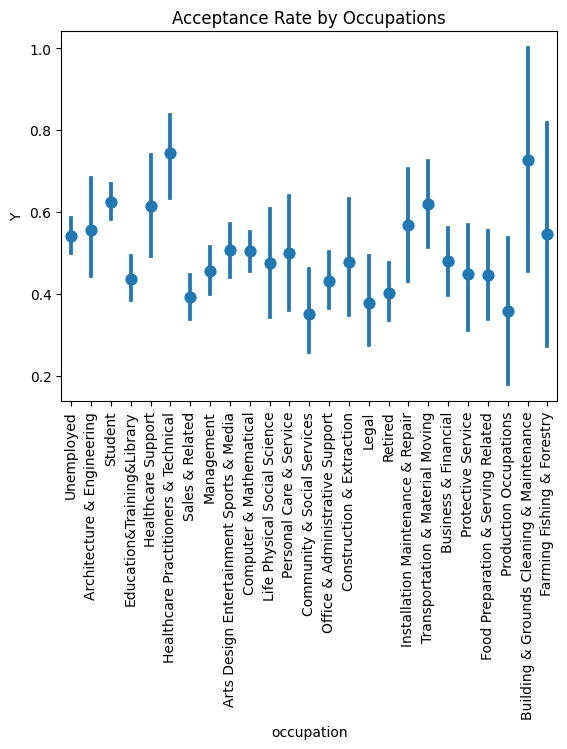

In [55]:
sns.pointplot(
    data=cafe_df,
    x='occupation',
    y='Y',
    linestyles=''
)
plt.xticks(rotation=90);
plt.title("Acceptance Rate by Occupations")

<Figure size 1200x600 with 0 Axes>

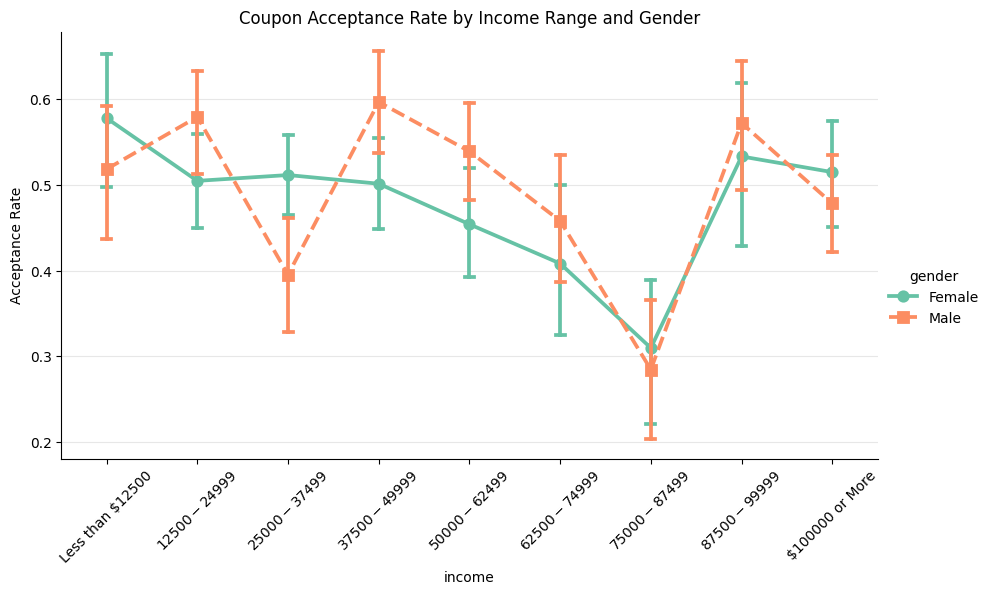

In [56]:
# I want to study affect of income on acceptance rate, separated by gender
income_order = [
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999',
    '$50000 - $62499',
    '$62500 - $74999',
    '$75000 - $87499',
    '$87500 - $99999',
    '$100000 or More'
]

plt.figure(figsize=(12, 6))

sns.catplot(
    data=cafe_df,
    kind='point',            
    x='income',
    y='Y',
    hue='gender',
    order=income_order,
    errorbar='ci',
    capsize=0.1,
    height=5,
    aspect=1.8,
    palette='Set2',
    markers=['o', 's'],
    linestyles=['-', '--']
)

plt.title("Coupon Acceptance Rate by Income Range and Gender")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()